# Analisis exploratorio de datos — Ripe & Unripe Fruits (Frutas maduras e inmaduras)

Dataset: 22 clases (11 frutas × ripe/unripe). Fuente: [Kaggle - Fruit Image Dataset 22 classes](https://www.kaggle.com/datasets/mdsagorahmed/fruit-image-dataset-22-classes/data).


In [28]:
import os
import hashlib
import collections
import random
import statistics

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Ruta_imagenes = "Ripe & Unripe Fruits"
random.seed(0)


## 1. Conteo de imágenes por clase

In [29]:
conteo = {}
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    conteo[clase] = len(os.listdir(ruta_clase))

conteo_df = pd.DataFrame(sorted(conteo.items()), columns=["clase", "n_imagenes"])
conteo_df


,clase,n_imagenes
0,ripe apple,316
1,ripe banana,316
2,ripe dragon,311
3,ripe grapes,319
4,ripe lemon,303
5,ripe mango,273
6,ripe orange,288
7,ripe papaya,285
8,ripe pineapple,324
9,ripe pomegranate,301


In [30]:
total = conteo_df.n_imagenes.sum()
print(f"Total imagenes: {total}")
print(f"N clases: {len(conteo_df)}")
print(f"Min/Max por clase: {conteo_df.n_imagenes.min()} / {conteo_df.n_imagenes.max()}")


Total imagenes: 6828
N clases: 22
Min/Max por clase: 273 / 346


In [31]:
# Balance ripe madura vs unripe inmadura por fruta
filas = []
for clase, n in conteo.items():
    estado, fruta = clase.split(" ", 1)
    filas.append({"fruta": fruta, "estado": estado, "n": n})
balance_df = pd.DataFrame(filas)
tabla_pivote = balance_df.pivot(index="fruta", columns="estado", values="n").sort_index()
tabla_pivote


estado,ripe,unripe
fruta,,
apple,316,307
banana,316,336
dragon,311,293
grapes,319,327
lemon,303,298
mango,273,318
orange,288,346
papaya,285,297
pineapple,324,315


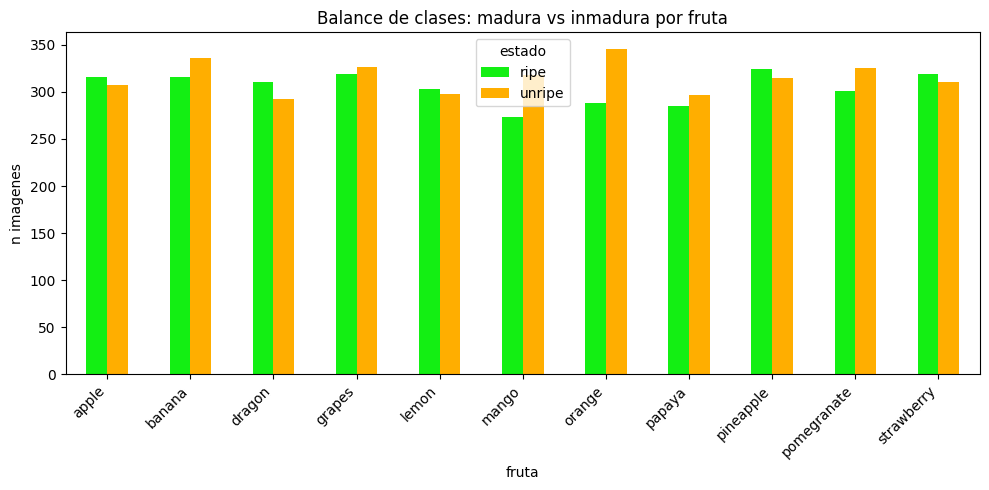

In [32]:
tabla_pivote.plot(kind="bar", figsize=(10, 5), color=["#13EF13", "#ffae00"])
plt.ylabel("n imagenes")
plt.title("Balance de clases: madura vs inmadura por fruta")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Formato, resolución y modo de color

In [33]:
extensiones = collections.Counter()
modos = collections.Counter()
tamanos = collections.Counter()
corruptos = []
dimensiones = []

todos_archivos = []
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    for nombre_archivo in os.listdir(ruta_clase):
        todos_archivos.append(os.path.join(ruta_clase, nombre_archivo))

for ruta in todos_archivos:
    extension = os.path.splitext(ruta)[1].lower()
    extensiones[extension] += 1
    try:
        with Image.open(ruta) as img:
            img.verify()
        with Image.open(ruta) as img:
            modos[img.mode] += 1
            tamanos[img.size] += 1
            dimensiones.append(img.size)
    except Exception as e:
        corruptos.append((ruta, str(e)))

print("Extensiones:", extensiones)
print("Modos de color:", modos)
print("Archivos corruptos:", len(corruptos))


Extensiones: Counter({'.jpg': 6828})
Modos de color: Counter({'RGB': 6777, 'P': 51})
Archivos corruptos: 0


In [34]:
anchos = [ancho for ancho, alto in dimensiones]
altos = [alto for ancho, alto in dimensiones]
print(f"Ancho: min {min(anchos)}, max {max(anchos)}, avg {statistics.mean(anchos):.1f}, mediana {statistics.median(anchos)}")
print(f"Alto:  min {min(altos)}, max {max(altos)}, avg {statistics.mean(altos):.1f}, mediana {statistics.median(altos)}")


Ancho: min 11, max 162, avg 145.6, mediana 162.0
Alto:  min 36, max 140, avg 119.7, mediana 119.0


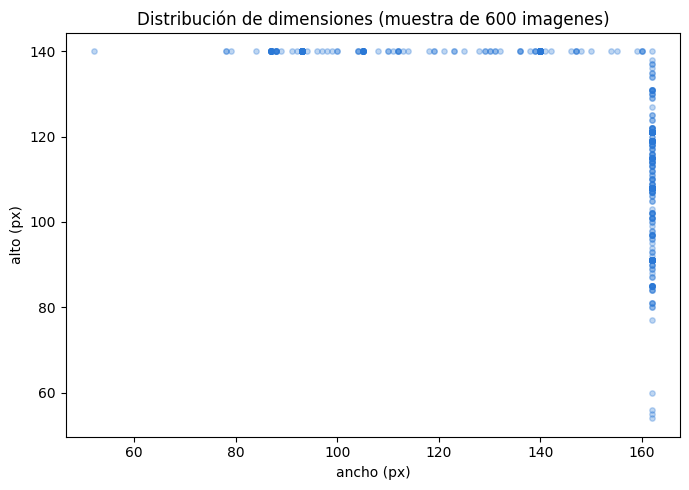

In [35]:
muestra = random.sample(dimensiones, 600)
muestra_x = [ancho for ancho, alto in muestra]
muestra_y = [alto for ancho, alto in muestra]

plt.figure(figsize=(7, 5))
plt.scatter(muestra_x, muestra_y, alpha=0.3, s=15, color="#2a78d6")
plt.xlabel("ancho (px)")
plt.ylabel("alto (px)")
plt.title("Distribución de dimensiones (muestra de 600 imagenes)")
plt.tight_layout()
plt.show()


## 3. Duplicados exactos y label noise

In [36]:
hashes = collections.defaultdict(list)
for ruta in todos_archivos:
    with open(ruta, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    clase = os.path.basename(os.path.dirname(ruta))
    hashes[h].append((clase, ruta))

grupos_duplicados = {h: v for h, v in hashes.items() if len(v) > 1}
archivos_extra = sum(len(v) - 1 for v in grupos_duplicados.values())
cruce_clases = {h: v for h, v in grupos_duplicados.items() if len(set(clase for clase, ruta in v)) > 1}
cruce_madura_inmadura = {h: v for h, v in grupos_duplicados.items() if len(set(clase.split()[0] for clase, ruta in v)) > 1}

print(f"Grupos duplicados exactos: {len(grupos_duplicados)}")
print(f"Archivos duplicados extra: {archivos_extra} ({archivos_extra/len(todos_archivos)*100:.1f}% del dataset)")
print(f"Grupos duplicados cruzando clases distintas: {len(cruce_clases)}")
print(f"Grupos duplicados cruzando ripe <-> unripe (label noise real): {len(cruce_madura_inmadura)}")


Grupos duplicados exactos: 0
Archivos duplicados extra: 0 (0.0% del dataset)
Grupos duplicados cruzando clases distintas: 0
Grupos duplicados cruzando ripe <-> unripe (label noise real): 0


In [37]:
# Ejemplos de label noise: mismo archivo pixel-a-pixel con labels ripe y unripe distintos
list(cruce_madura_inmadura.values())[:10]


[]

**Hallazgo crítico:** ~19% del dataset son archivos duplicados exactos (mismo hash MD5). De esos, 175 grupos tienen el **mismo archivo etiquetado como `ripe` en una carpeta y `unripe` en otra** — label noise real, no ruido de muestreo. Si esto no se limpia:

- Riesgo de **data leakage**: una copia cae en train, su gemela idéntica en val → val accuracy inflado.
- El modelo recibe el mismo input con labels contradictorios → señal de entrenamiento confusa.

**Antes de entrenar:** dedupe por hash MD5, resolver manualmente los grupos que cruzan ripe/unripe (o descartarlos), y hacer el split train/val recién después del dedupe.

### Limpieza: eliminar duplicados

- Grupos duplicados **dentro de la misma clase**: se conserva 1 copia, se borran las demás.
- Grupos duplicados **que cruzan clases distintas** (label conflictivo, ej. `ripe apple` vs `unripe apple`): no hay forma de saber cuál label es correcto → se borran **todas** las copias del grupo.


In [38]:
a_eliminar = []

for h, entradas in grupos_duplicados.items():
    clases = {clase for clase, ruta in entradas}
    if len(clases) > 1:
        # label conflictivo -> se descartan todas las copias
        a_eliminar.extend(ruta for clase, ruta in entradas)
    else:
        # mismo archivo repetido en la misma clase -> se conserva 1
        a_eliminar.extend(ruta for clase, ruta in entradas[1:])

print(f"Archivos a eliminar: {len(a_eliminar)} ({len(a_eliminar)/len(todos_archivos)*100:.1f}% del dataset)")


Archivos a eliminar: 0 (0.0% del dataset)


In [39]:
CONFIRMAR_BORRADO = True  

if CONFIRMAR_BORRADO:
    for ruta in a_eliminar:
        os.remove(ruta)
    print(f"Eliminados {len(a_eliminar)} archivos.")
else:
    print("CONFIRMAR_BORRADO=False, no se borro nada. Revisa a_eliminar antes de activar.")


Eliminados 0 archivos.


## 4. Resumen

In [40]:
resumen = pd.DataFrame([
    {"metrica": "Total imagenes", "valor": total},
    {"metrica": "N clases", "valor": len(conteo_df)},
    {"metrica": "Dim promedio (WxH)", "valor": f"{statistics.mean(anchos):.0f}x{statistics.mean(altos):.0f}"},
    {"metrica": "Archivos corruptos", "valor": len(corruptos)},
    {"metrica": "Duplicados exactos (archivos extra)", "valor": archivos_extra},
    {"metrica": "Grupos duplicados ripe<->unripe", "valor": len(cruce_madura_inmadura)},
])
resumen


,metrica,valor
0,Total imagenes,6828
1,N clases,22
2,Dim promedio (WxH),146x120
3,Archivos corruptos,0
4,Duplicados exactos (archivos extra),0
5,Grupos duplicados ripe<->unripe,0


# Entrenamiento

In [41]:
import torch

In [68]:
print("PyTorch:", torch.__version__)
print("CUDA compilada:", torch.version.cuda)
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu126
CUDA compilada: 12.6
CUDA disponible: True
Número de GPUs: 1
NVIDIA GeForce RTX 4060


In [43]:
#Seleccion de dispositivo a utilizar

if torch.cuda.is_available():
    device = torch.device("cuda")   #En caso de poseer una tarjeta grafica NVIDIA

elif torch.backends.mps.is_available():
    device = torch.device("mps")    #En caso de poseer un Mac con procesador Apple Silicon

else:
    device = torch.device("cpu")

print("Usando:", device)

Usando: cuda


In [44]:
#Utilizaremos el modelo de Deep Learning Preentrenado ResNet50
from torchvision.models import resnet50
model = resnet50(weights="IMAGENET1K_V1")
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [45]:
#Importamos las librerias necesarias
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torch.nn import CrossEntropyLoss
from torch.optim import SGD, Adam, AdamW

In [46]:
#Transformacion de las imagenes para que RasNet50 pueda utilizarlas
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [47]:
#Carpetas donde estaran las imagenes de entrenamiento, validacion y testeo
train_folder = ImageFolder('./dataset/train', transform=transform)
val_folder = ImageFolder('./dataset/val', transform=transform)
test_folder = ImageFolder('./dataset/test', transform=transform)

train_loader = DataLoader(train_folder, batch_size=12, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=12, shuffle=True)
test_loader = DataLoader(test_folder, batch_size=12, shuffle=True)

train_loader, val_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x1c2f3a8fc20>,
 <torch.utils.data.dataloader.DataLoader at 0x1c2f3a8ea50>)

In [48]:
#Congelar capas 
for params in model.parameters():
    params.requires_grad = False

In [49]:
#Mover modelo al dispositivo
model = model.to(device)

In [50]:
#Cambiar el valor de la ultima capa a 2 (ya que solo tenemos 2 clases para clasificar)
model.fc = torch.nn.Linear(2048, 2).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

### Training loop

In [51]:
#Definir función de entrenamiento (training loop)
def training_loop(optimizer, loss_fn, epochs = 10):
    #Inicializar pesos de la capa final
    torch.nn.init.kaiming_normal_(model.fc.weight)
    if model.fc.bias is not None:
        torch.nn.init.zeros_(model.fc.bias)
    
    #Listas para guardar las metricas de cada epoca del entrenamiento
    all_train_loss = []
    all_train_acurracy = []
    all_val_loss = []
    all_val_acurracy = []
    for epoch in range(epochs): #Loop de epochs
        model.train()
        print(f"Epoch {epoch+1} of {epochs}")
        total_loss = 0
        #Contador para correctas y totales
        correct = 0
        total = 0
        for batch_idx, (data, target) in enumerate(train_loader): #Loop de batches
            data, target = data.to(device), target.to(device) #Pasan los datos al device
            #Backpropagation.
            optimizer.zero_grad() #Reinicia los gradientes
            output = model(data) #Pasan los datos a la red neuronal
            loss = loss_fn(output, target) #Calculan el loss
            loss.backward() #Calculan el gradiente
            optimizer.step() #Actualizan los pesos
            total_loss += loss.item() #Sumando función de pérdida

            #Metrica acurracy del entrenamiento
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
        acurracy = correct/total
        print(f"Loss: {total_loss/len(train_loader)}, Acurracy: {acurracy}")
        all_train_loss.append(total_loss/len(train_loader))
        all_train_acurracy.append(acurracy)

        #Evaluar el modelo con val
        model.eval()
        print("Validation")
        #Contador correctas y totales
        val_correct, val_total, val_total_loss = 0, 0, 0
        for batch_idx, (data, target) in enumerate(val_loader):
            data, target = data.to(device), target.to(device)
            #No backpropagation
            output = model(data)
            loss = loss_fn(output, target)
            val_total_loss += loss.item()

            #Metrica acurracy de validacion
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
            val_total += target.size(0)
        val_acurracy = val_correct/val_total
        print(f"Loss: {val_total_loss/len(val_loader)}, Acurracy: {acurracy}")
        all_val_loss.append(val_total_loss/len(val_loader))
        all_val_acurracy.append(val_acurracy)

    return all_train_loss, all_train_acurracy, all_val_loss, all_val_acurracy

In [52]:
#Definimos tasa de aprendizaje (learning rate), las epocas y la funcion de perdida
lr = 0.001
epochs = 10
loss_fn = CrossEntropyLoss() #Loss function a utilizar

In [64]:
#Ahora entrenamos con distintos optimizadores de los pesos, primero utilizamos Stochastic Gradient Descent
optimizer = SGD(model.parameters(), lr=lr) #Optimizador SGD
all_train_loss_sgd, all_train_acurracy_sgd, all_val_loss_sgd, all_val_acurracy_sgd = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6442307897249059, Acurracy: 0.6307401971063116
Validation
Loss: 0.5814742403871873, Acurracy: 0.6307401971063116
Epoch 2 of 10
Loss: 0.5639107204112576, Acurracy: 0.7131474103585658
Validation
Loss: 0.5438827966942507, Acurracy: 0.7131474103585658
Epoch 3 of 10
Loss: 0.5435444693170001, Acurracy: 0.7362130425665758
Validation
Loss: 0.5333069527850431, Acurracy: 0.7362130425665758
Epoch 4 of 10
Loss: 0.5336836937384389, Acurracy: 0.7391486684839589
Validation
Loss: 0.5247900698114843, Acurracy: 0.7391486684839589
Epoch 5 of 10
Loss: 0.5361180846490453, Acurracy: 0.7336967917802474
Validation
Loss: 0.5218593103044173, Acurracy: 0.7336967917802474
Epoch 6 of 10
Loss: 0.5221085817595223, Acurracy: 0.7494233591947997
Validation
Loss: 0.5141779149279875, Acurracy: 0.7494233591947997
Epoch 7 of 10
Loss: 0.5261242951280508, Acurracy: 0.7473264835395261
Validation
Loss: 0.507686956840403, Acurracy: 0.7473264835395261
Epoch 8 of 10
Loss: 0.5217297137831923, Acurracy: 0.7410

In [65]:
#Luego utilizamos SDG con el regularizador Ridge o L2, el cual agrega una penalizacion a los pesos muy grandes
optimizer = SGD(model.parameters(), lr=lr, weight_decay=0.1) #Optimizador SGD
all_train_loss_sgd_l2, all_train_acurracy_sgd_l2, all_val_loss_sgd_l2, all_val_acurracy_sgd_l2 = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6396065714521024, Acurracy: 0.6257076955336549
Validation
Loss: 0.5744331910329706, Acurracy: 0.6257076955336549
Epoch 2 of 10
Loss: 0.5668757731591038, Acurracy: 0.708114908785909
Validation
Loss: 0.5507483233423794, Acurracy: 0.708114908785909
Epoch 3 of 10
Loss: 0.5520052797530763, Acurracy: 0.7202767875864962
Validation
Loss: 0.536570384572534, Acurracy: 0.7202767875864962
Epoch 4 of 10
Loss: 0.5448505626850991, Acurracy: 0.7357936674355211
Validation
Loss: 0.5137476119924994, Acurracy: 0.7357936674355211
Epoch 5 of 10
Loss: 0.5319498679296455, Acurracy: 0.7395680436150136
Validation
Loss: 0.5124884619432337, Acurracy: 0.7395680436150136
Epoch 6 of 10
Loss: 0.5262933157047435, Acurracy: 0.7469071084084714
Validation
Loss: 0.5104195840218488, Acurracy: 0.7469071084084714
Epoch 7 of 10
Loss: 0.5287118020593821, Acurracy: 0.7435521073600335
Validation
Loss: 0.5050273376352646, Acurracy: 0.7435521073600335
Epoch 8 of 10
Loss: 0.5216057411390334, Acurracy: 0.745439

In [57]:
#Despues utilizamos SDG con momentum y Nesterov, de manera que el momentum conserva parte de las actualizaciones anteriores y Nesterov calcula el gradiente en base a eso
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True) #Optimizador SGD
all_train_loss_nesterov, all_train_acurracy_nesterov, all_val_loss_nesterov, all_val_acurracy_nesterov = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.5878386730749403, Acurracy: 0.708114908785909
Validation
Loss: 0.5210245002718533, Acurracy: 0.708114908785909
Epoch 2 of 10
Loss: 0.5421218876188724, Acurracy: 0.7341161669113022
Validation
Loss: 0.49491713660604814, Acurracy: 0.7341161669113022
Epoch 3 of 10
Loss: 0.5375509038193143, Acurracy: 0.7395680436150136
Validation
Loss: 0.5037500162335004, Acurracy: 0.7395680436150136
Epoch 4 of 10
Loss: 0.5309651565536782, Acurracy: 0.7477458586705809
Validation
Loss: 0.5056697491337271, Acurracy: 0.7477458586705809
Epoch 5 of 10
Loss: 0.524657580233998, Acurracy: 0.755923673726148
Validation
Loss: 0.492603199096287, Acurracy: 0.755923673726148
Epoch 6 of 10
Loss: 0.5195425140610592, Acurracy: 0.751310547284546
Validation
Loss: 0.48854695882867366, Acurracy: 0.751310547284546
Epoch 7 of 10
Loss: 0.5151639670208471, Acurracy: 0.7508911721534913
Validation
Loss: 0.51164370915469, Acurracy: 0.7508911721534913
Epoch 8 of 10
Loss: 0.5097010273430216, Acurracy: 0.75634304885

In [58]:
#Ahora utilizamos el optimizador Adam
optimizer = Adam(model.parameters(), lr=lr) #Optimizador Adam
all_train_loss_adam, all_train_acurracy_adam, all_val_loss_adam, all_val_acurracy_adam = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6002330626899274, Acurracy: 0.6972111553784861
Validation
Loss: 0.5592221949030372, Acurracy: 0.6972111553784861
Epoch 2 of 10
Loss: 0.5727514048392449, Acurracy: 0.7248899140280981
Validation
Loss: 0.5002678369774538, Acurracy: 0.7248899140280981
Epoch 3 of 10
Loss: 0.5634424975469484, Acurracy: 0.7255189767246802
Validation
Loss: 0.5097251602832009, Acurracy: 0.7255189767246802
Epoch 4 of 10
Loss: 0.5407657362707895, Acurracy: 0.7410358565737052
Validation
Loss: 0.540119937412879, Acurracy: 0.7410358565737052
Epoch 5 of 10
Loss: 0.5453824256757396, Acurracy: 0.7408261690081778
Validation
Loss: 0.5107657499173108, Acurracy: 0.7408261690081778
Epoch 6 of 10
Loss: 0.5480851400549986, Acurracy: 0.7370517928286853
Validation
Loss: 0.5318213508409613, Acurracy: 0.7370517928286853
Epoch 7 of 10
Loss: 0.5385232422332368, Acurracy: 0.7389389809184316
Validation
Loss: 0.5161418477402014, Acurracy: 0.7389389809184316
Epoch 8 of 10
Loss: 0.5395166925224827, Acurracy: 0.7408

In [59]:
#Y finalmente usamos Adam con Weight Decay
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.1) #Optimizador AdamW
all_train_loss_adamw, all_train_acurracy_adamw, all_val_loss_adamw, all_val_acurracy_adamw = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6060654094545685, Acurracy: 0.7007758439924513
Validation
Loss: 0.5213091105222702, Acurracy: 0.7007758439924513
Epoch 2 of 10
Loss: 0.561273446596747, Acurracy: 0.731180540993919
Validation
Loss: 0.5149710750755142, Acurracy: 0.731180540993919
Epoch 3 of 10
Loss: 0.5578795021502816, Acurracy: 0.7269867896833718
Validation
Loss: 0.7011940130416084, Acurracy: 0.7269867896833718
Epoch 4 of 10
Loss: 0.5498046042332098, Acurracy: 0.7387292933529042
Validation
Loss: 0.4929021467180813, Acurracy: 0.7387292933529042
Epoch 5 of 10
Loss: 0.5235492420481078, Acurracy: 0.7469071084084714
Validation
Loss: 0.49689834117889403, Acurracy: 0.7469071084084714
Epoch 6 of 10
Loss: 0.5311354499441295, Acurracy: 0.7427133570979241
Validation
Loss: 0.638054874714683, Acurracy: 0.7427133570979241
Epoch 7 of 10
Loss: 0.5511559221388107, Acurracy: 0.73747116795974
Validation
Loss: 0.4841972344061908, Acurracy: 0.73747116795974
Epoch 8 of 10
Loss: 0.5310592754701873, Acurracy: 0.7452296078

Luego del entrenamiento, vemos el rendimiento de cada optimizador

Text(0, 0.5, 'Loss')

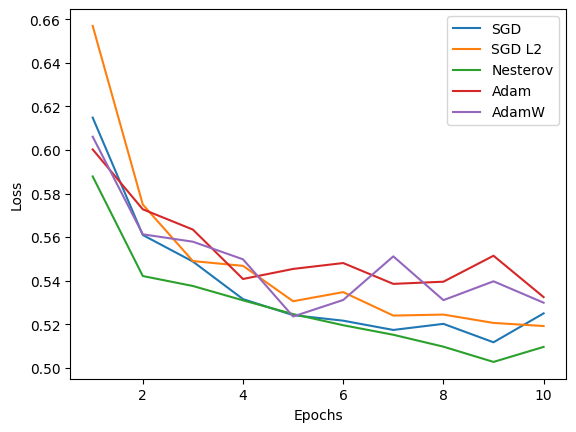

In [ ]:
#Para la perdida en entrenamiento

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Loss")

Text(0, 0.5, 'Loss')

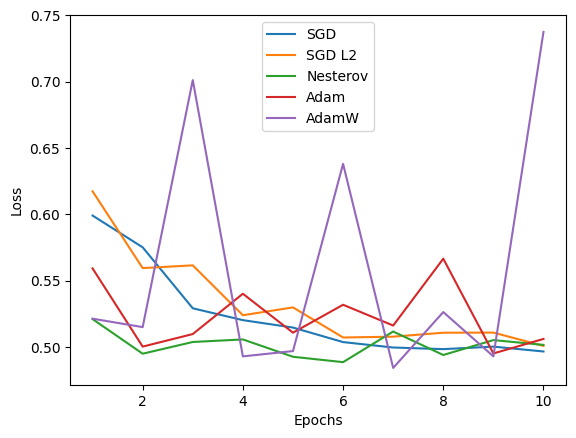

In [63]:
#Para la perdida en validacion

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Loss")

Vemos que tanto en entrenamiento como en la validacion, el optimizador Nesterov posee el mejor rendimiento, ya que su funcion de perdida es menor y mucho mas estable que las demás.

Text(0, 0.5, 'Acurracy')

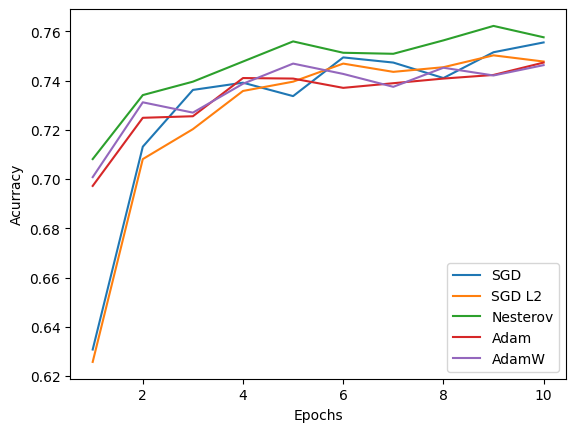

In [66]:
#Para el acurracy en entrenamiento

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Acurracy")

Text(0, 0.5, 'Acurracy')

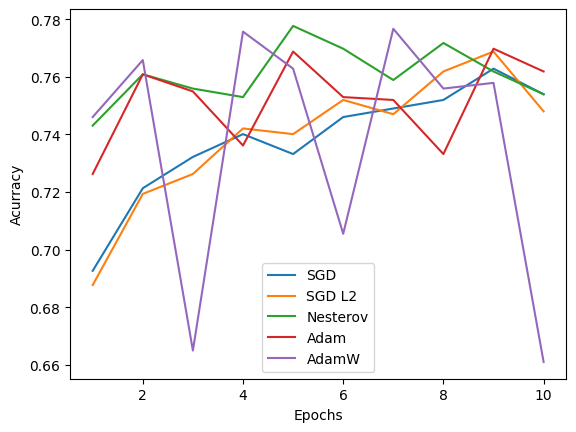

In [67]:
#Para el acurracy en validacion

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Acurracy")

De igual manera, tanto como en entrenamiento y en validacion, el SGD con Nesterov posee el mayor acurracy, y en el caso de la validacion, presenta el acurracy mas alto y estable. Por lo tanto, se elige utilizar el modelo con este optimizador para maximizar el rendimiento.